# Manual QC and optotag

In [1]:
import os
import numpy as np
import mat73
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import pyNeuroDAP as ndap

/Users/shunli/miniconda3/envs/pyNeuroDAP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
# Read data
exp_name = '202512-Ephys-LHb'
session_name = '20251202-SL412-Random1_g0'

session_path = rf'/Users/shunli/Projects/pyNeuroDAP/Data/{session_name}'
spike_path = os.path.join(session_path, rf'AIND_{session_name}')
save_folder = os.path.join(session_path, 'results', session_name)
os.makedirs(save_folder, exist_ok=True)

# Set sampling frequencies
apFs = 30000
behaviorFs = 10000
photometryFs = 50
cameraFs = 50

# Read the tsv files 
print(spike_path)
tvs_files = [f for f in os.listdir(spike_path) if f.endswith('.tsv')]
print(tvs_files)
# Read the npy files
npy_files = [f for f in os.listdir(spike_path) if f.endswith('.npy')]
print(npy_files)

# Load cluster group and cluster info
cluster_group = pd.read_csv(os.path.join(spike_path, 'cluster_group.tsv'), sep='\t')
cluster_info = pd.read_csv(os.path.join(spike_path, 'cluster_info.tsv'), sep='\t')
cluster_info = cluster_info.merge(cluster_group, on='global_unit_ids')
cluster_group.head()
cluster_info.head()

/Users/shunli/Projects/pyNeuroDAP/Data/20251202-SL412-Random1_g0/AIND_20251202-SL412-Random1_g0
['cluster_info.tsv', 'template_metrics.tsv', 'cluster_group.tsv', 'cluster_info_enhanced.tsv']
['spike_times.npy', 'spike_clusters.npy', 'best_channel_templates.npy']


,amplitude_cutoff,amplitude_cv_median,amplitude_cv_range,amplitude_median,d_prime,drift_mad,drift_ptp,drift_std,firing_range,firing_rate,...,repolarization_slope,spread,velocity_above,velocity_below,peak_channel,segment_name,n_samples,trough_to_peak_ms,global_unit_ids,labels
0,0.000981,0.265789,0.476454,-75.683590,4.188790,1.436474,6.128739,0.976870,3.6,1.758339,...,377551.887922,120,NaN,NaN,90,block0_imec0.ap_recording1,296,0.400000,1,mua
1,0.025831,7.164167,19.256293,-3.027344,1.265933,NaN,NaN,NaN,1.2,0.368075,...,26829.199234,180,NaN,346.269819,196,block0_imec0.ap_recording1,296,0.200000,2,noise
2,0.001798,0.342331,0.157169,-57.519530,3.362427,1.703349,6.250656,1.989732,7.8,7.489977,...,177272.166525,90,NaN,NaN,90,block0_imec0.ap_recording1,296,0.433333,3,mua
3,NaN,NaN,NaN,-33.300780,7.336112,NaN,NaN,NaN,0.6,0.209212,...,506380.633880,45,NaN,NaN,90,block0_imec0.ap_recording1,296,0.033333,4,sua
4,0.000452,0.309466,0.262481,-72.656250,1.993241,0.787202,6.318970,1.271930,9.8,11.187219,...,225700.004720,90,-3200.340783,NaN,90,block0_imec0.ap_recording1,296,0.433333,5,mua


## Manual QC

In [3]:
# Manual QC based on quality metrics

# ISI violation ratio < 0.5
# presence ratio > 0.8
# amplitude cutoff < 0.1
ISI_violation_ratio_cutoff = 0.5
presence_ratio_cutoff = 0.8
amplitude_cutoff = 0.1
# let add a coulume the cluster_info that indecet that whter is pass or fail of quality metrics assessment


cluster_info['quality'] = True
cluster_info.loc[(cluster_info['isi_violations_ratio'] > ISI_violation_ratio_cutoff) | # if the ISI_violation_ratio is greater than the cutoff
                    (cluster_info['presence_ratio'] < presence_ratio_cutoff) | # if the presence_ratio is less than the cutoff
                    (cluster_info['amplitude_cutoff'] > 0.1) | # if the amplitude_cutoff is greater than the cutoff
                    (cluster_info['labels'] == 'noise'), # if the label is noise
                    'quality'] = False
# let merge the cluster_info with the cluster_group on the global_cluster_id
cluster_info.head()

#let have cluster info inhanced with the np and save it to npy file
cluster_info_enhanced = cluster_info
# save the cluster_info_enhanced to the data folder as tsv file
cluster_info_enhanced.to_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t', index=False)

# let print number of the neurons that pass the quality metrics
print(cluster_info['quality'].value_counts())

quality
True     125
False     95
Name: count, dtype: int64


In [4]:
# let's add the qualioty column to the cluster_group
print('Random forest label for neurons that pass QC')
print(cluster_info[cluster_info['quality'] == True]['labels'].value_counts())

print('Random forest label for neurons that fail QC')
print(cluster_info[cluster_info['quality'] == False]['labels'].value_counts())

Random forest label for neurons that pass QC
labels
mua    72
sua    53
Name: count, dtype: int64
Random forest label for neurons that fail QC
labels
noise    71
mua      23
sua       1
Name: count, dtype: int64


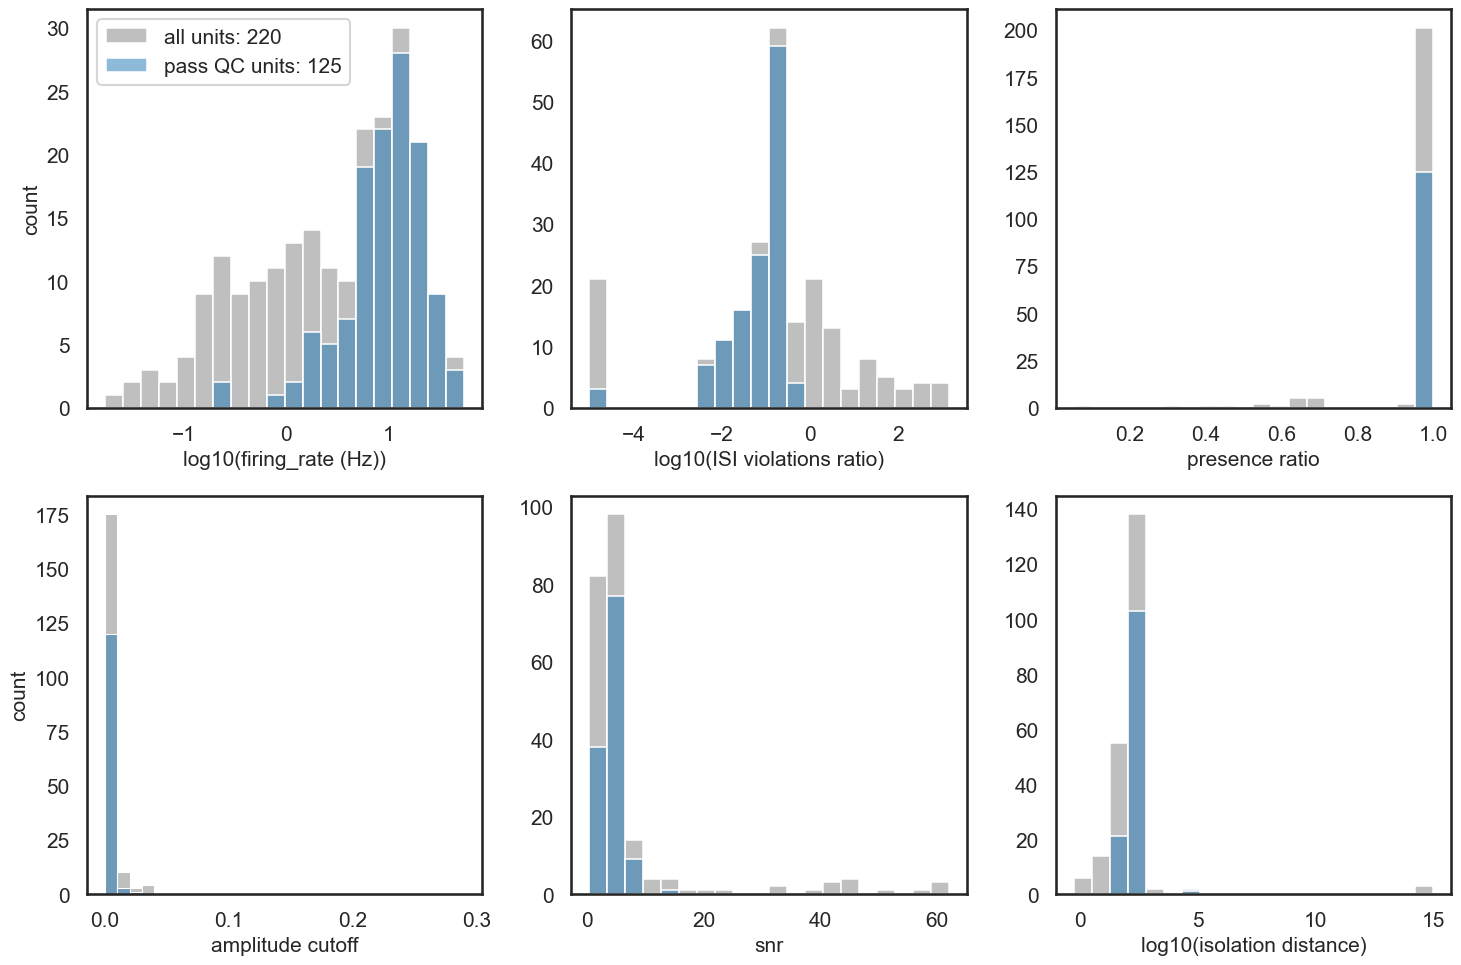

In [5]:
# in this histogram we have all units in the gray and that ovelay the units that pass the quality metrics in the green
num_of_bins = 20
font_size = 15
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
# let do the firing rate histogram in the log scale
fr_log = np.log10(cluster_info['firing_rate'])
bins_fr = np.histogram_bin_edges(fr_log, bins=num_of_bins)
sns.histplot(fr_log, bins=bins_fr, color='gray', ax=ax[0, 0], edgecolor=None, alpha=0.5)
sns.histplot(fr_log[cluster_info['quality']], bins=bins_fr, ax=ax[0, 0], edgecolor=None, alpha=0.5)
ax[0, 0].set_xlabel('log10(firing_rate (Hz))', fontsize=font_size)

# let do the isi_violations_ratio histogram
ISI_vio_log = np.log10(cluster_info['isi_violations_ratio']+10**-5)
bins_ISI_vio = np.histogram_bin_edges(ISI_vio_log, bins=num_of_bins)
sns.histplot(ISI_vio_log, bins=bins_ISI_vio, color='gray', ax=ax[0, 1], edgecolor=None, alpha=0.5)
sns.histplot(ISI_vio_log[cluster_info['quality']], bins=bins_ISI_vio, ax=ax[0, 1], edgecolor=None, alpha=0.5)
ax[0, 1].set_xlabel('log10(ISI violations ratio)', fontsize=font_size)

# let do the presence_ratio histogram
present_ratio = cluster_info['presence_ratio']
bins_present_ratio = np.histogram_bin_edges(present_ratio, bins=num_of_bins)
sns.histplot(present_ratio, bins=bins_present_ratio, color='gray', ax=ax[0, 2], edgecolor=None, alpha=0.5)
sns.histplot(present_ratio[cluster_info['quality']], bins=bins_present_ratio, ax=ax[0, 2], edgecolor=None, alpha=0.5)
ax[0, 2].set_xlabel('presence ratio', fontsize=font_size)

# let do the amplitude_cutoff histogram
amplitude_cutoff = cluster_info['amplitude_cutoff']
bins_amplitude_cutoff = np.arange(0, .3, .01) 
sns.histplot(amplitude_cutoff, bins=bins_amplitude_cutoff, color='gray', ax=ax[1, 0], edgecolor=None, alpha=0.5)
sns.histplot(amplitude_cutoff[cluster_info['quality']], bins=bins_amplitude_cutoff, ax=ax[1, 0], edgecolor=None, alpha=0.5)
ax[1, 0].set_xlabel('amplitude cutoff', fontsize=font_size)

# let do the snr histogram
snr = cluster_info['snr']
bins_snr = np.histogram_bin_edges(snr, bins=num_of_bins)
sns.histplot(snr, bins=bins_snr, color='gray', ax=ax[1, 1], edgecolor=None, alpha=0.5)
sns.histplot(snr[cluster_info['quality']], bins=bins_snr, ax=ax[1, 1], edgecolor=None, alpha=0.5)
ax[1, 1].set_xlabel('snr', fontsize=font_size)

# let do the isolation_distance histogram
isolation_distance = np.log10(cluster_info['isolation_distance']+10**-5)
# let remove the nan values from the isolation_distance
isolation_distance = isolation_distance[~np.isnan(isolation_distance)]
bins_isolation_distance = np.histogram_bin_edges(isolation_distance, bins=num_of_bins)
sns.histplot(isolation_distance, bins=bins_isolation_distance, color='gray', ax=ax[1, 2], edgecolor=None, alpha=0.5)
sns.histplot(isolation_distance[cluster_info['quality']], bins=bins_isolation_distance, ax=ax[1, 2], edgecolor=None, alpha=0.5)
ax[1, 2].set_xlabel('log10(isolation distance)', fontsize=font_size)
# let add the legend to the plot
ax[0, 0].legend([f'all units: {len(fr_log)}', f'pass QC units: {len(fr_log[cluster_info["quality"]])}'], fontsize=font_size)

# let set the font size of the x and y labels and the ticks to the 15
for i in range(2):
    for j in range(3):
        ax[i, j].tick_params(axis='both', which='major', labelsize=15)
        # remmove the y label all the subplots
        if j != 0:
            ax[i, j].set_ylabel('')
        else:
            ax[i, j].set_ylabel('count', fontsize=font_size)
plt.tight_layout()
plt.show()

# let save the figure
fig.savefig(os.path.join(save_folder, 'quality_metrics.png'), dpi=300)
fig.savefig(os.path.join(save_folder, 'quality_metrics.pdf'), dpi=300)

## Optotag

### Load spike data

In [6]:
# Setup Fs
apFs = 30000
behaviorFs = 10000
cameraFs = 50

# Load spike data
spike_times = np.load(os.path.join(spike_path, 'spike_times.npy'), allow_pickle=True).flatten()
spike_clusters = np.load(os.path.join(spike_path, 'spike_clusters.npy'), allow_pickle=True).flatten()
segment_index = np.zeros_like(spike_times)  # Always 0
spikes = np.stack([spike_times, spike_clusters, segment_index], axis=1)
print(f'Converted spikes shape: {spikes.shape}')
print(f'First 5 spikes:\n{spikes[:5]}')

# Extract good units
cluster_info_enhanced = pd.read_csv(os.path.join(spike_path, 'cluster_info_enhanced.tsv'), sep='\t')
good_units = cluster_info_enhanced[cluster_info_enhanced['quality']]['global_unit_ids'].values
print(f'Number of good units: {len(good_units)}')

Converted spikes shape: (3992110, 3)
First 5 spikes:
[[  1 174   0]
 [  1  64   0]
 [  1 220   0]
 [  1  66   0]
 [  2  48   0]]
Number of good units: 125


### Load behavior & photometry data

In [ ]:
# Load sync_*.mat
sync_times = ndap.load_mat(os.path.join(session_path, rf'sync_{session_name}.mat'))
params = ndap.convert_params_from_mat(sync_times)

# Load behavior data
data_mat = ndap.load_mat(os.path.join(session_path, rf'data_{session_name}.mat'))
water = data_mat['rightSolenoid'].flatten() if 'rightSolenoid' in data_mat else None
lick = data_mat['rightLick'].flatten() if 'rightLick' in data_mat else None
tone = data_mat['rightTone'].flatten() if 'rightTone' in data_mat else None
blueLaser = data_mat['blueLaser'].flatten() if 'blueLaser' in data_mat else None
redLaser = data_mat['redLaser'].flatten() if 'redLaser' in data_mat else None
airpuff = data_mat['airpuff'].flatten() if 'airpuff' in data_mat else None
# Extract onset times for continuous events (water, tone, lick) - all rising edges
water_onsets = ndap.get_onset_times(water, edge='rising')
tone_onsets = ndap.get_onset_times(tone, edge='rising')
lick_onsets = ndap.get_onset_times(lick, edge='rising')
airpuff_onsets = ndap.get_onset_times(airpuff, edge='rising')
# Extract onset times for laser events (filtered by >=500ms separation)
blueLaser_onsets = ndap.get_onset_times(blueLaser, fs=behaviorFs, min_separation=0.5, edge='falling')
redLaser_onsets = ndap.get_onset_times(redLaser, fs=behaviorFs, min_separation=1, edge='falling')

# Load photometry data
timeseries_mat = ndap.load_mat(os.path.join(session_path, rf'timeseries_{session_name}.mat'))
# Extract DA photometry
DA = timeseries_mat['timeSeries']['data'][timeseries_mat['timeSeries']['name'].index('dLight')]
photometryFs = timeseries_mat['timeSeries']['finalFs'][timeseries_mat['timeSeries']['name'].index('dLight')].item()


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


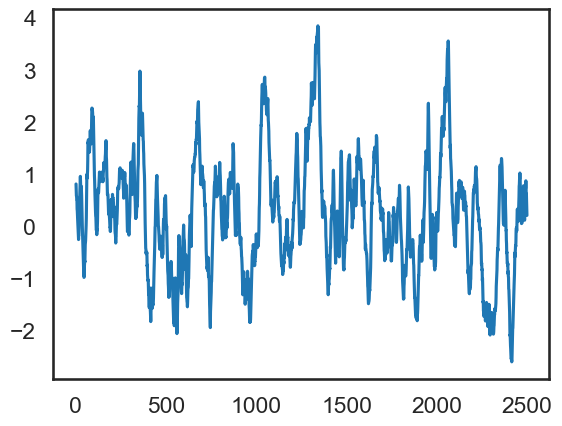

In [ ]:
plt.plot(DA[:int(50*photometryFs)])
plt.show()

### Plot PSTH of good units near opto onset

In [ ]:
# Align spikes blue stim
bin_size = 5           # in ms
time_range = (-0.2,0.5)     # in sec
xaxis = ndap.get_time_axis(time_range, bin_size_ms=bin_size)

print('Aligning spikes to blue laser onsets...')
aligned_blue_stim = ndap.get_spikes(spikes, redLaser_onsets, time_range, 
                                    include_units=good_units, 
                                    same_system=False, params=params, 
                                    bin_size_ms=bin_size)
print(f'Finished: aligned {len(blueLaser_onsets)} blue laser events')
print(f'Shape: {aligned_blue_stim["rate"].shape} (units, events, bins)')


Aligning spikes to blue laser onsets...
Finished: aligned 52 blue laser events
Shape: (125, 1527, 140) (units, events, bins)


In [ ]:
# Plot PSTH aligned to blue stim

# Get spike rate data: shape (units, events, bins)
aligned = aligned_blue_stim
spike_rates = aligned['rate']  # Shape: (n_units, n_events, n_bins)
spike_times = aligned['times']
n_units = spike_rates.shape[0]

# Calculate number of rows and columns for subplots
n_cols = 5
n_rows = int(np.ceil(n_units / n_cols))
# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
axes = axes.flatten() if n_units > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes.flatten()

# Plot PSTH for each unit
for unit_idx in range(n_units):
    ax = axes[unit_idx]
    unit_id = good_units[unit_idx]
    
    # ndap.plot_sem(spike_rates[unit_idx, :, :], x=xaxis, ax=ax)
    ndap.plot_raster(spike_times[unit_idx], x=xaxis, ax=ax)
    
    # Labels and formatting
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1, alpha=0.7) # Add vertical line at t=0 (stimulus onset)
    ax.set_xlabel('Time (ms)', fontsize=9)
    ax.set_ylabel('Firing Rate (Hz)', fontsize=9)
    ax.set_title(f'Unit {unit_id}', fontsize=10)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for idx in range(n_units, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(os.path.join(save_folder, 'PSTH_blue_stim_all_units.png'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(save_folder, 'PSTH_blue_stim_all_units.pdf'), dpi=300, bbox_inches='tight')
print(f'Saved PSTH plots for {n_units} units')


KeyboardInterrupt: 